# Import Libraries 

In [1]:
import ee


print("Authenticating with Google Earth Engine...")
ee.Authenticate()

print("Initializing project...")
ee.Initialize(project="agriculture-drought-assesment")

Authenticating| with Google Earth Engine...
Initializing project...


In [2]:
import importlib

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from data import indices, load_CHIRPS, load_ERA5, load_S2, utils
from visualisation import index_plotter

importlib.reload(indices)
importlib.reload(load_S2)
importlib.reload(load_ERA5)
importlib.reload(load_CHIRPS)
importlib.reload(utils)
importlib.reload(index_plotter)

ModuleNotFoundError: No module named 'data'

# Prepare DataFrame

In [64]:
def get_master_df(region, i_date, f_date):

    print(f"Loading Sentinel-2 dataset for periods {i_date} to {f_date}...")
    s2_clouded = load_S2.get_s2_data(region, i_date, f_date)

    print(f"Loading ERA5 Land data for periods {i_date} to {f_date}...")
    era5_data = load_ERA5.get_era5_data(region, i_date, f_date)

    print(f"Loading CHIRPS Climate Data for periods {i_date} to {f_date}...")
    chirps_data = load_CHIRPS.get_chirps_data(region, i_date, f_date)

    s2_clear_sky = s2_clouded.map(load_S2.s2_clear_sky)

    reducer_fn = utils.create_reducer(region, scale=10)
    ndvi_df = indices.get_index_df(s2_clear_sky, indices.NDVI, reducer_fn)
    ndre_df = indices.get_index_df(s2_clear_sky, indices.NDRE, reducer_fn)
    ndwi_df = indices.get_index_df(s2_clear_sky, indices.NDWI, reducer_fn)

    reducer_fn = utils.create_reducer(region, scale=20)
    slvw_df = load_ERA5.get_soil_levels_df(era5_data, reducer_fn, "water")
    slt_df = load_ERA5.get_soil_levels_df(era5_data, reducer_fn, "temp")
    temp_2m_df = load_ERA5.get_temp_2m_df(era5_data, reducer_fn)
    ssrd_df = load_ERA5.get_ssrd(era5_data, reducer_fn)

    reducer_fn = utils.create_reducer(region, scale=5566)
    perc_df = load_CHIRPS.get_precipitation_df(chirps_data, reducer_fn)

    grouped = indices.apply_groupby_date(ndwi_df, ndvi_df, ndre_df)
    ndwi_df_grouped = grouped[0]
    ndvi_df_grouped = grouped[1]
    ndre_df_grouped = grouped[2]

    master_df = utils.merge_with_master(
        ndvi_df_grouped,
        ndwi_df_grouped,
        ndre_df_grouped,
        slvw_df,
        slt_df,
        temp_2m_df,
        ssrd_df,
        perc_df,
    )
    print("Done!")
    return master_df



In [65]:
region = utils.get_region()
i_date = "2019-01-01"
f_date = "2023-12-31"
master_df = get_master_df(region, i_date, f_date)

Loading Sentinel-2 dataset for periods 2019-01-01 to 2023-12-31...
Loading ERA5 Land data for periods 2019-01-01 to 2023-12-31...
Loading CHIRPS Climate Data for periods 2019-01-01 to 2023-12-31...
Creating NDVI DataFrame...
Creating NDRE DataFrame...
Creating NDWI DataFrame...
Creating volumetric_soil_water_layer_1 DataFrame...
Creating volumetric_soil_water_layer_2 DataFrame...
Creating volumetric_soil_water_layer_3 DataFrame...
Creating volumetric_soil_water_layer_4 DataFrame...
Concatinated water levels DataFrame.
Creating soil_temperature_level_1 DataFrame...
Creating soil_temperature_level_2 DataFrame...
Creating soil_temperature_level_3 DataFrame...
Creating soil_temperature_level_4 DataFrame...
Concatinated temp levels DataFrame.
Creating temperature_2m DataFrame...
Creating surface_solar_radiation_downwards_sum DataFrame...
Creating precipitation DataFrame...
Done!


In [46]:
master_df.to_csv("master_df.csv")

# Time-series visualisation

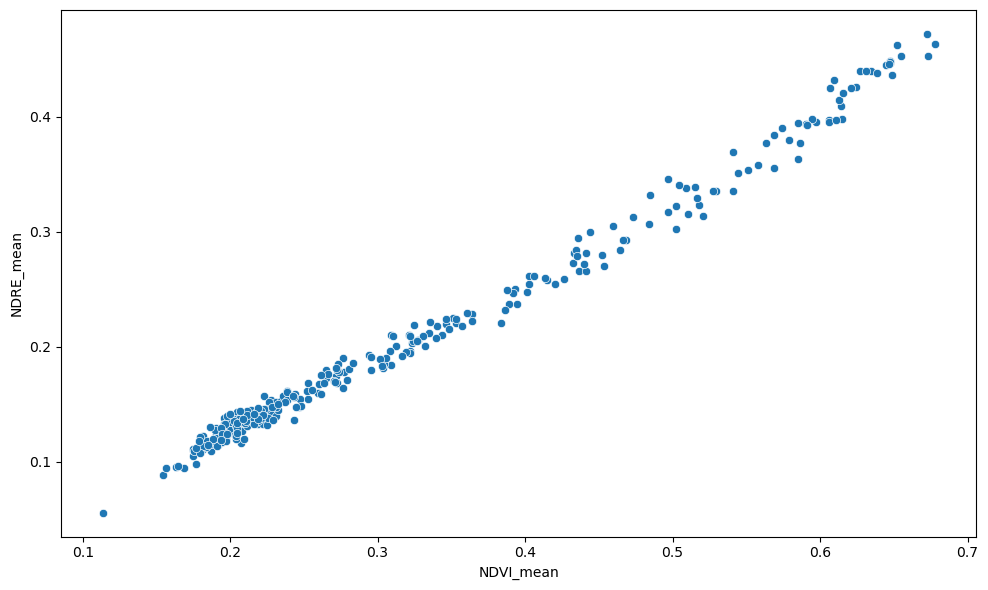

In [48]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=master_df, x="NDVI_mean", y="NDRE_mean")
plt.tight_layout()
plt.show()

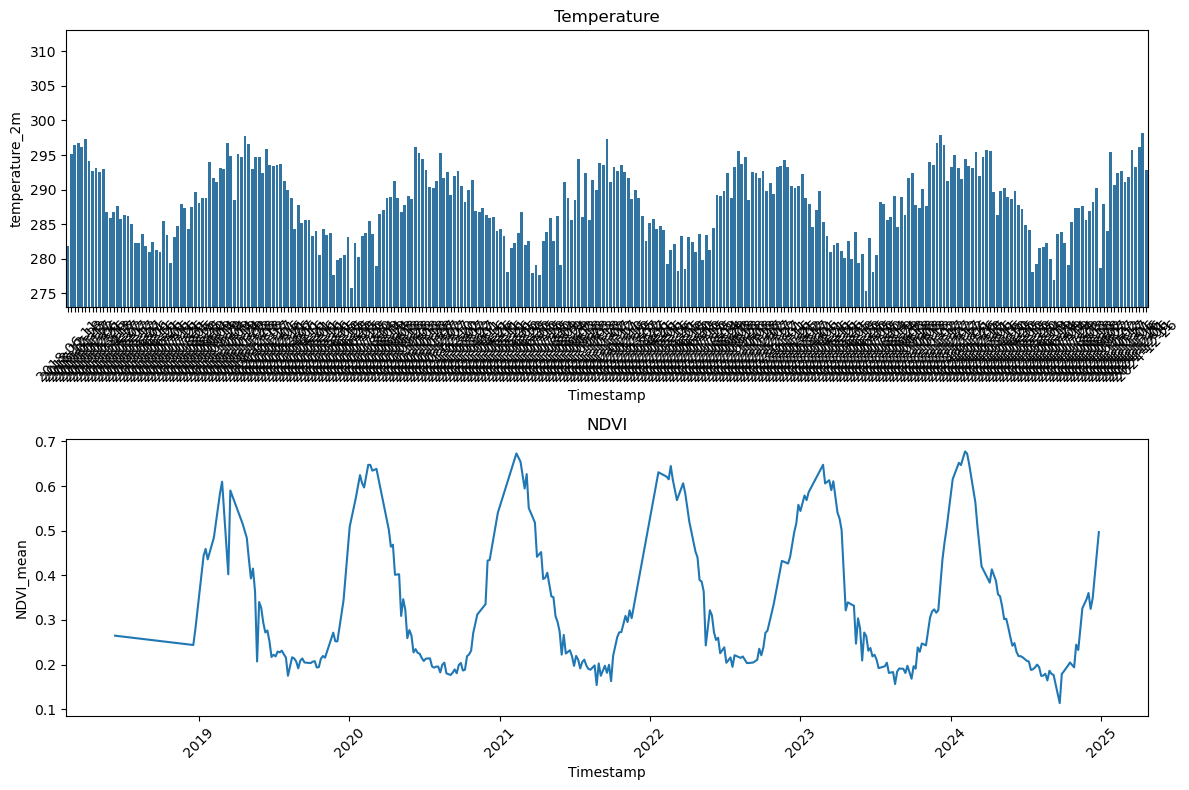

In [49]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))


sns.barplot(data=master_df, x="Timestamp", y="temperature_2m", ax=ax1)
ax1.set_title('Temperature')
ax1.tick_params(axis='x', rotation=45)
ax1.set_ylim(273, )

sns.lineplot(data=master_df, x="Timestamp", y="NDVI_mean", ax=ax2)
ax2.set_title('NDVI')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [57]:
master_df["DOY"] = master_df["Timestamp"].dt.dayofyear
master_df["Year"] = pd.DatetimeIndex(master_df["Timestamp"]).year
master_df.head()

,Timestamp,NDVI_mean,NDVI_std,NDWI_mean,NDWI_std,NDRE_mean,NDRE_std,volumetric_soil_water_layer_1,volumetric_soil_water_layer_2,volumetric_soil_water_layer_3,volumetric_soil_water_layer_4,soil_temperature_level_1,soil_temperature_level_2,soil_temperature_level_3,soil_temperature_level_4,temperature_2m,surface_solar_radiation_downwards_sum,DOY,Year
0,2018-06-11,0.264834,0.027659,-0.018403,0.011886,0.172670,0.016877,0.306751,0.304871,0.332898,0.270195,282.936783,283.268878,285.246988,289.844360,281.841531,1.396077e+07,162,2018
1,2018-12-18,0.243970,0.000000,-0.055244,0.000000,0.158551,0.000000,0.308989,0.306355,0.264311,0.269061,297.882347,297.381037,294.788019,291.030538,295.141863,2.736125e+07,352,2018
2,2018-12-23,0.279125,0.018347,-0.050020,0.002971,0.171111,0.010849,0.277944,0.282902,0.263698,0.268994,299.395327,297.602217,295.118181,291.294381,296.456970,3.166161e+07,357,2018
3,2019-01-12,0.443624,0.005769,0.055141,0.010164,0.299517,0.002777,0.304470,0.287806,0.262007,0.268745,298.505361,296.989556,294.899146,292.265817,296.709403,3.345829e+07,12,2019
4,2019-01-17,0.459222,0.000000,0.082007,0.000000,0.304681,0.000000,0.263420,0.268432,0.261469,0.268640,300.629040,299.118729,296.054570,292.477596,296.114802,2.853415e+07,17,2019


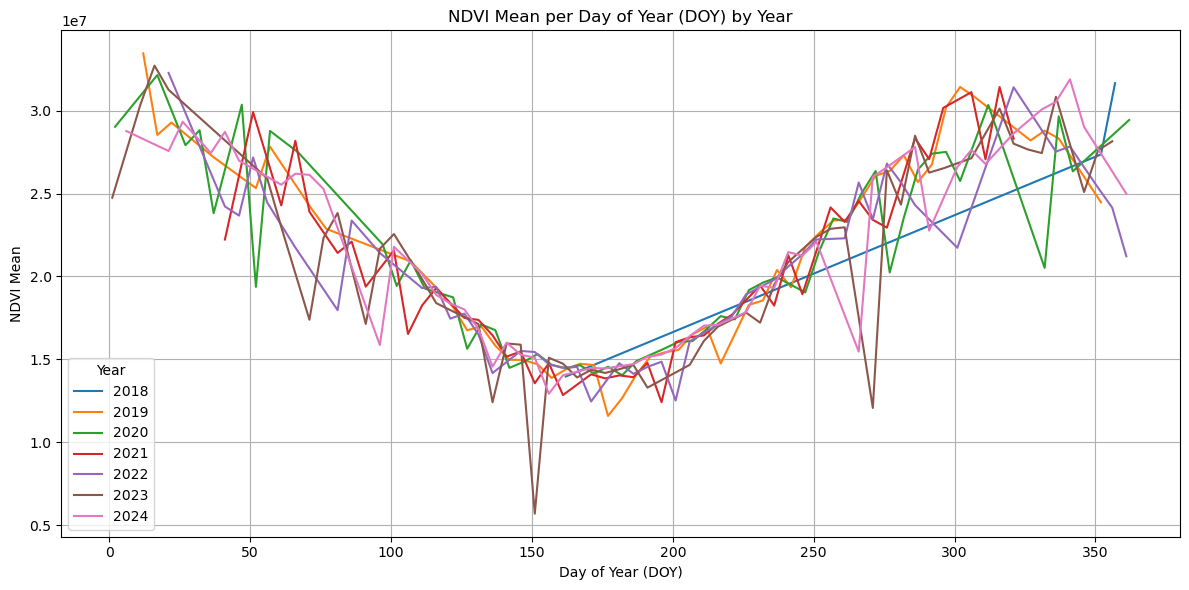

In [58]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=master_df, x="DOY", y="surface_solar_radiation_downwards_sum", hue="Year", palette="tab10")
plt.title("NDVI Mean per Day of Year (DOY) by Year")
plt.xlabel("Day of Year (DOY)")
plt.ylabel("NDVI Mean")
plt.legend(title="Year")
plt.grid(True)
plt.tight_layout()
plt.show()
